C:\Users\anant\AppData\Local\Temp\ipykernel_14280\3610275354.py:86: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(pad=3.0)   # additional spacing safety


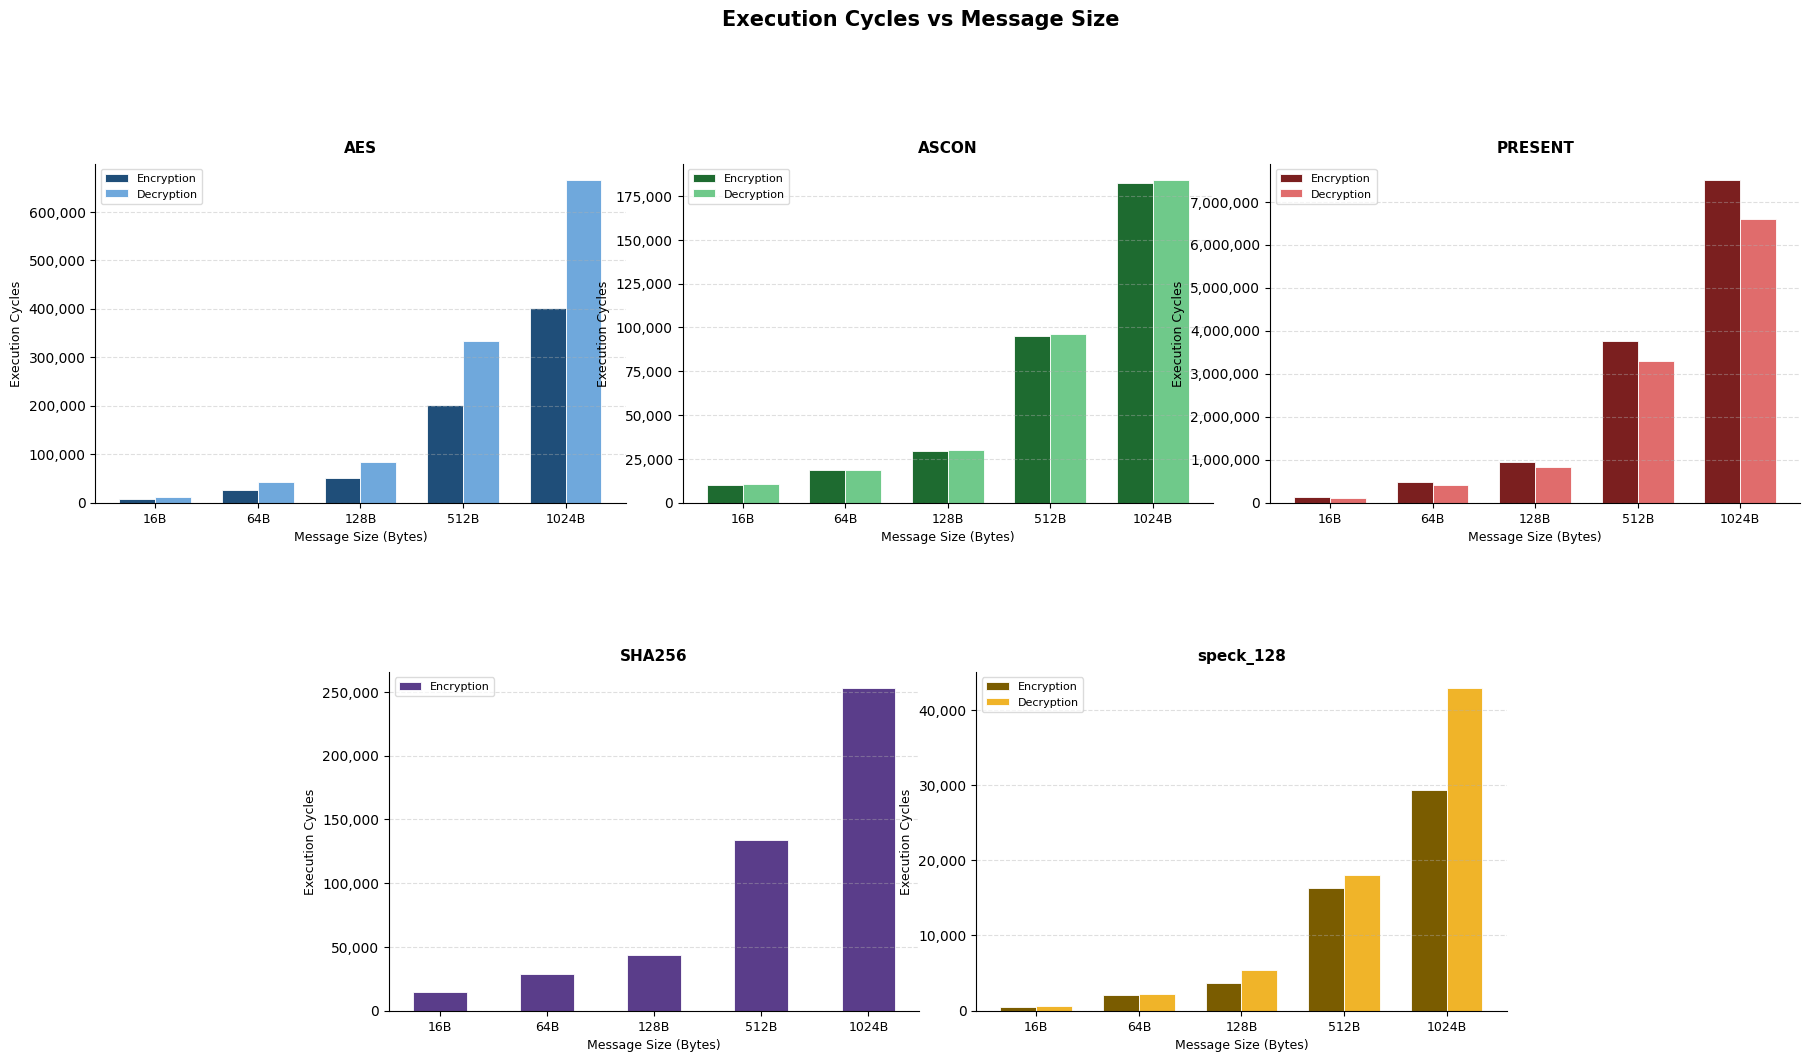

C:\Users\anant\AppData\Local\Temp\ipykernel_14280\3610275354.py:86: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(pad=3.0)   # additional spacing safety


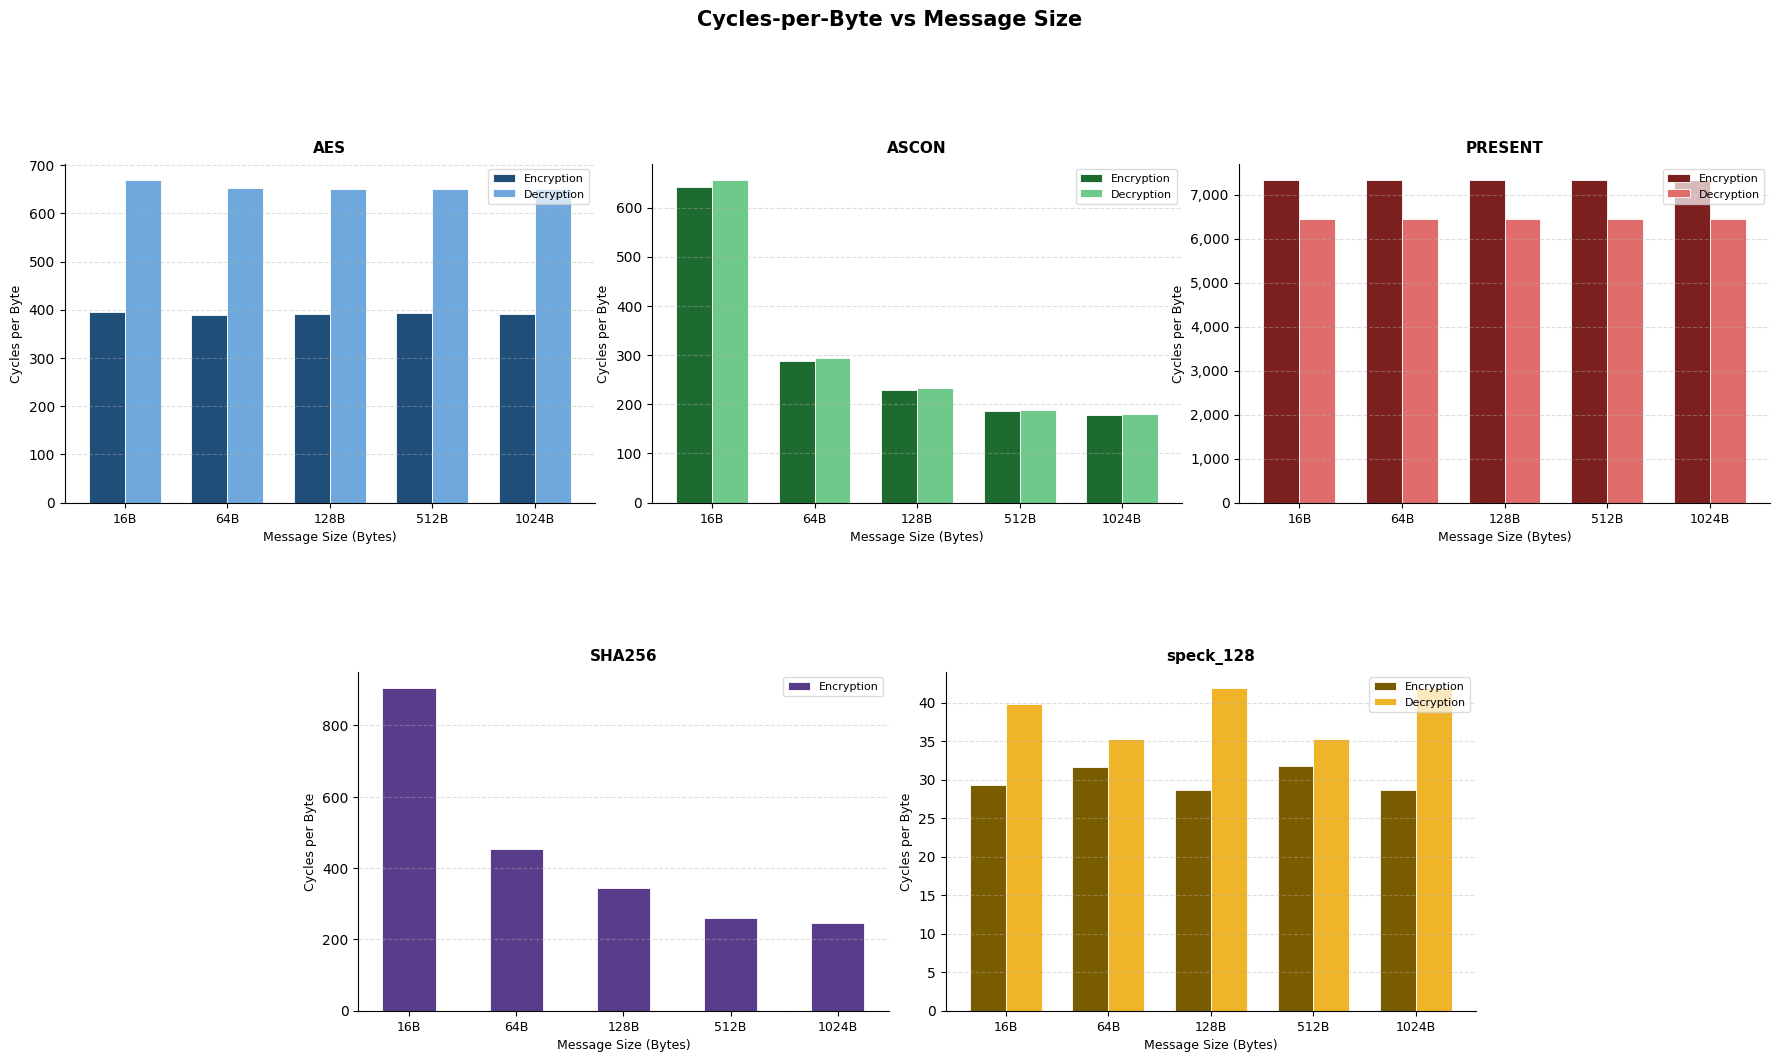

C:\Users\anant\AppData\Local\Temp\ipykernel_14280\3610275354.py:86: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(pad=3.0)   # additional spacing safety


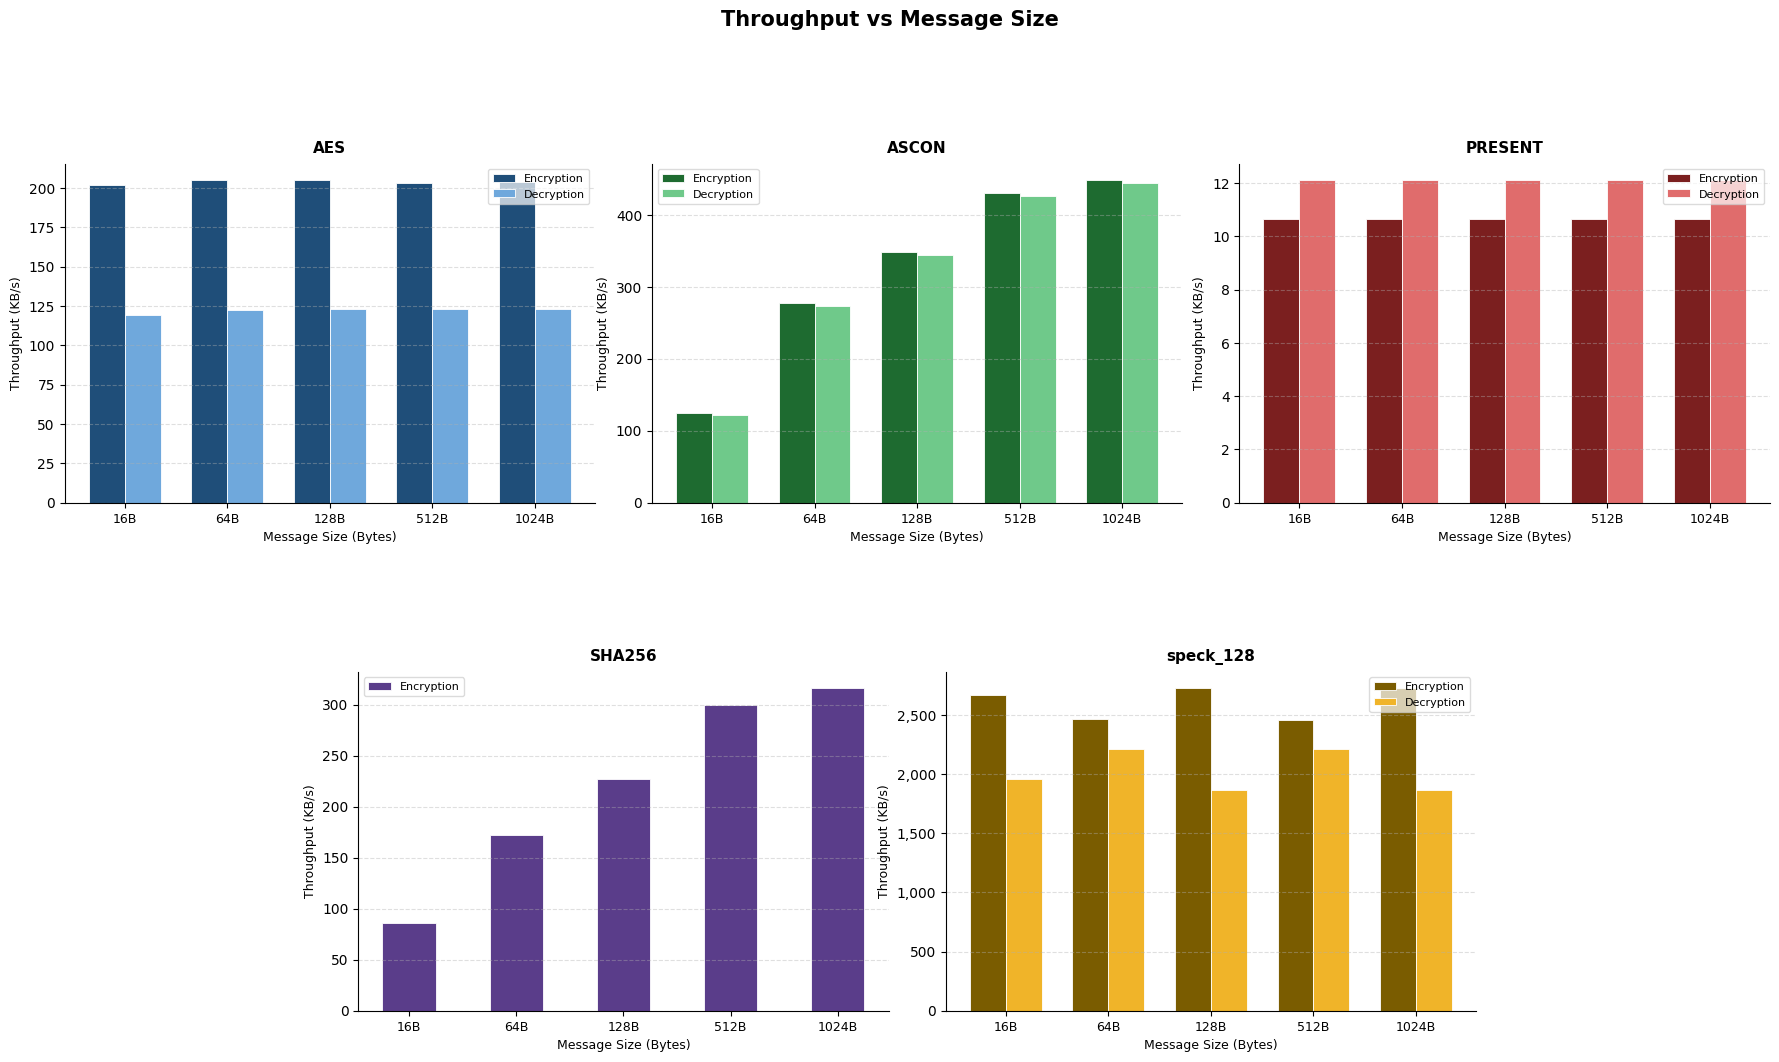

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

# ── Load data ──────────────────────────────────────────────────────────────────
df = pd.read_excel('Workbook1.xlsx', header=0)
df.columns = (
    df.columns
    .str.strip()
    .str.replace(" ", "_")
    .str.replace("(", "")
    .str.replace(")", "")
)
df['Message_Size'] = df['Message_Size'].astype(int)

def parse_algo(name):
    name = str(name).strip()
    if name.endswith('_ENC'): return name[:-4], 'ENC'
    elif name.endswith('_DEC'): return name[:-4], 'DEC'
    else: return name, 'ENC'

df[['AlgoBase', 'Direction']] = df['Algorithm'].apply(lambda x: pd.Series(parse_algo(x)))

algo_order = ['AES', 'ASCON', 'PRESENT', 'SHA256', 'speck_128']
payloads   = [16, 64, 128, 512, 1024]

palette = {
    'AES':       {'ENC': '#1f4e79', 'DEC': '#6fa8dc'},
    'ASCON':     {'ENC': '#1e6b30', 'DEC': '#6fc98a'},
    'PRESENT':   {'ENC': '#7b1f1f', 'DEC': '#e06c6c'},
    'SHA256':    {'ENC': '#5a3d8a', 'DEC': None},
    'speck_128': {'ENC': '#7a5c00', 'DEC': '#f0b429'},
}

def plot_algo_bar(ax, algo, metric_col, ylabel):
    sub     = df[df['AlgoBase'] == algo].copy()
    has_dec = 'DEC' in sub['Direction'].values
    x     = np.arange(len(payloads))
    width = 0.35 if has_dec else 0.5
    enc_vals, dec_vals = [], []
    for p in payloads:
        row_enc = sub[(sub['Message_Size'] == p) & (sub['Direction'] == 'ENC')]
        enc_vals.append(float(row_enc[metric_col].values[0]) if len(row_enc) else 0)
        if has_dec:
            row_dec = sub[(sub['Message_Size'] == p) & (sub['Direction'] == 'DEC')]
            dec_vals.append(float(row_dec[metric_col].values[0]) if len(row_dec) else 0)
    offset = width / 2 if has_dec else 0
    ax.bar(x - offset, enc_vals, width, color=palette[algo]['ENC'], edgecolor='white', linewidth=0.6, label='Encryption')
    if has_dec:
        ax.bar(x + offset, dec_vals, width, color=palette[algo]['DEC'], edgecolor='white', linewidth=0.6, label='Decryption')
    ax.set_xticks(x)
    ax.set_xticklabels([f'{p}B' for p in payloads], fontsize=9)
    ax.set_xlabel('Message Size (Bytes)', fontsize=9)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.set_title(algo, fontsize=11, fontweight='bold', pad=8)
    ax.legend(fontsize=8, framealpha=0.7)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:,.0f}'))
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    ax.spines[['top', 'right']].set_visible(False)

def make_figure(title, metric_col, ylabel, filename):
    fig = plt.figure(figsize=(22, 11))   # increased width

    fig.suptitle(title, fontsize=15, fontweight='bold', y=1.02)

    # Increased spacing between plots
    gs = gridspec.GridSpec(
        2, 18,
        figure=fig,
        hspace=0.50,
        wspace=1.40   # key fix: prevents Y-axis overlap
    )

    axes = [
        fig.add_subplot(gs[0, 0:6]),    # AES
        fig.add_subplot(gs[0, 6:12]),   # ASCON
        fig.add_subplot(gs[0, 12:18]),  # PRESENT
        fig.add_subplot(gs[1, 3:9]),    # SHA256
        fig.add_subplot(gs[1, 9:15]),   # speck_128
    ]

    for ax, algo in zip(axes, algo_order):
        plot_algo_bar(ax, algo, metric_col, ylabel)

    plt.tight_layout(pad=3.0)   # additional spacing safety

    plt.savefig(filename, dpi=180, bbox_inches='tight')
    plt.show()

# ── Chart 1: Execution Cycles ──────────────────────────────────────────────────
make_figure('Execution Cycles vs Message Size',
            'Exec_cycles_per_run_us', 'Execution Cycles',
            'chart1_execution_cycles.png')

# ── Chart 2: Cycles-per-Byte ───────────────────────────────────────────────────
make_figure('Cycles-per-Byte vs Message Size',
            'cyc_per_byte', 'Cycles per Byte',
            'chart2_cycles_per_byte.png')

# ── Chart 3: Throughput ────────────────────────────────────────────────────────
make_figure('Throughput vs Message Size',
            'throughput_KBps', 'Throughput (KB/s)',
            'chart3_throughput.png')

In [11]:
print(df.columns)

Index(['Algorithm', 'Message_Size', 'Exec_cycles_per_run_us',
       'Exec_time_per_run_us', 'cyc_per_byte', 'throughput_KBps',
       'energy_per_op_uJ', 'energy_per_byte_uJ', 'flash_size', 'ram_size',
       'stack_size', 'AlgoBase', 'Direction'],
      dtype='str')
